# Лабораторная работа №3: Метод K-ближайших соседей (KNN)

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

## 1. Загрузка и первичная обработка данных

В качестве набора данных мы снова используем знаменитый датасет Titanic. Он отлично подходит для задачи бинарной классификации (выжил/не выжил).

Загружаем данные и проводим первичный анализ.

In [167]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline 
sns.set(style="ticks")

In [41]:
data = pd.read_csv('Titanic-Dataset.csv', sep=",")

In [43]:
data.shape

(891, 12)

In [45]:
# проверим есть ли пропущенные значения
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Предобработка данных

Для обучения модели KNN необходимо выполнить предобработку данных:

1) Удалить неинформативные колонки (PassengerId, Name, Ticket, Cabin).
2) Закодировать категориальные признаки (Sex, Embarked) в числовой формат с помощью LabelEncoder.
3) Заполнить пропуски в колонке Age медианным значением (это устойчивая оценка центра для данного распределения).

In [47]:
# Копируем данные
data_processed = data.copy()

In [49]:
#удаление сталбца Cabin - смысла в нем, потому что он нам ничего сказать не может 
data_processed = data_processed.drop('Cabin', axis=1)
data_processed.shape

(891, 11)

In [57]:
# кодируем категориальные признаки Sex и Embarked
data_processed['Sex'] = LabelEncoder().fit_transform(data_processed['Sex']) # male->0, female->1
data_processed['Embarked'] = LabelEncoder().fit_transform(data_processed['Embarked']) # S->0, C->1, Q->2
data_processed.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [59]:
# заполняем пропуски в Age медианой
data_processed['Age'] = data_processed['Age'].fillna(data_processed['Age'].median())
data_processed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 2. Разделение выборки на обучающую и тестовую

Разделим данные на матрицу признаков X и целевую переменную y. В качестве целевой переменной выступает колонка Survived.

In [61]:
# формируем X и y
y = data_processed['Survived']
X = data_processed.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

Используем функцию train_test_split для разделения данных. Мы выделим 20% данных в тестовую выборку. Параметр stratify=y гарантирует, что соотношение классов (выживших и погибших) в обучающей и тестовой выборках будет таким же, как и в исходном датасете. random_state=42 фиксирует случайность для воспроизводимости результатов.

In [67]:
# разделяем выборку
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% данных в тест, 80% в обучение
    random_state=42,      # фиксация для воспроизводимости
    stratify=y            # сохраняет исходное соотношение классов (выжил/не выжил)
)

In [69]:
# Проверка размеров
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (712, 7), y_train: (712,)
X_test:  (179, 7), y_test:  (179,)


## 3. Реализация алгоритма KNN

Для глубокого понимания алгоритма мы реализуем его самостоятельно. Создадим класс SimpleKNN, который будет вычислять евклидово расстояние и предсказывать класс или значение для новых объектов.

In [71]:
from operator import itemgetter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

Здесь мы также создаем перечисление PredictionType для разделения задач классификации и регрессии.

In [73]:
from enum import Enum
class PredictionType(Enum):
    CLASSIFICATION = 1
    REGRESSION = 2

In [ ]:
class SimpleKNN:
    
    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        """Метод обучения — запоминает обучающую выборку"""
        self._X_train = X_train.reset_index(drop=True)  # сброс индекса
        self._y_train = y_train.reset_index(drop=True)
          
    def eucl_dist(self, p: np.ndarray, q: np.ndarray) -> float:
        """Евклидово расстояние"""
        return math.sqrt(sum([(pi - qi) ** 2 for pi, qi in zip(p, q)]))
            
    def predict_for_single_object(self, K: int, 
                prediction_type: PredictionType, 
                X_o: np.ndarray, 
                verbose=False) -> np.ndarray:
        """Предсказание для одного объекта"""
        neighbors_list = []
        
        for i in range(self._X_train.shape[0]):
            #используем .values для любых признаков
            data_train_current_x = self._X_train.iloc[i].values.astype(float)
            data_train_current_y = self._y_train.iloc[i]
            dist = self.eucl_dist(X_o, data_train_current_x)
            neighbors_list.append((data_train_current_y, dist, data_train_current_x))
        
        neighbors_list_sorted = sorted(neighbors_list, key=itemgetter(1))
        
        K_neighbors_list_sorted = neighbors_list_sorted[:K]
        
        if prediction_type == PredictionType.REGRESSION:
            arr = np.array([x for x, _, _ in K_neighbors_list_sorted])
            return np.mean(arr)          
        elif prediction_type == PredictionType.CLASSIFICATION:
            k_y_list = [y for y, _, _ in K_neighbors_list_sorted]
            k_y_list_grouped_temp = np.unique(k_y_list, return_counts=True)
            k_y_list_grouped = [[key, cnt] for key, cnt in zip(k_y_list_grouped_temp[0], k_y_list_grouped_temp[1])]
            k_y_list_grouped_sorted = sorted(k_y_list_grouped, key=itemgetter(1), reverse=True)
            return k_y_list_grouped_sorted[0][0]
        else:
            raise Exception('Неизвестный тип предсказания')
                   
    def predict(self, K: int, prediction_type: PredictionType, 
                X_test: pd.DataFrame, verbose=False) -> np.ndarray:
        """Предсказание для всей тестовой выборки"""
        test_data_temp = [X_test.iloc[i].values.astype(float) for i in range(X_test.shape[0])]
        return [self.predict_for_single_object(K=K, prediction_type=prediction_type, 
                X_o=i, verbose=verbose) for i in test_data_temp]

## 4. Обучение и оценка модели

### Подготовка данных для обучения

Объединим обучающие признаки и целевую переменную для удобства, чтобы затем создать дополнительный целевой признак для демонстрации регрессии.

In [79]:
data_train = pd.concat([X_train, y_train], axis=1)
data_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
692,3,1,28.0,0,0,56.4958,2,1
481,2,1,28.0,0,0,0.0000,2,0
527,1,1,28.0,0,0,221.7792,2,0
855,3,0,18.0,0,1,9.3500,2,1
801,2,0,31.0,1,1,26.2500,2,1
...,...,...,...,...,...,...,...,...
359,3,0,28.0,0,0,7.8792,1,1
258,1,0,35.0,0,0,512.3292,0,1
736,3,0,48.0,1,3,34.3750,2,0
462,1,1,47.0,0,0,38.5000,2,0


Для демонстрации работы KNN в регрессии мы создадим искусственную целевую переменную Fare_clas, которая будет категорией стоимости билета (A, B, C, D). Это также поможет нам визуализировать данные.

In [103]:
def fare_to_class(fare: float) -> str:
    if fare < 10:
        result = 'A'  # Третий класс, низкая цена
    elif fare < 30:
        result = 'B'  # Второй класс, средняя цена
    elif fare < 100:
        result = 'C'  # Первый/второй класс, высокая цена
    else:
        result = 'D'  # Первый класс, премиум
    return result

In [180]:
# формирование второго целевого признака для классификации
data_train['Fare_clas'] = \
data_train.apply(lambda row: fare_to_class(row['Fare']),axis=1)
data_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Fare_clas
565,3,1,24.0,2,0,24.1500,2,0,B
160,3,1,44.0,0,1,16.1000,2,0,B
553,3,1,22.0,0,0,7.2250,0,1,A
860,3,1,41.0,2,0,14.1083,2,0,B
241,3,0,28.0,1,0,15.5000,1,1,B
...,...,...,...,...,...,...,...,...,...
880,2,0,25.0,0,1,26.0000,2,1,B
91,3,1,20.0,0,0,7.8542,2,0,A
883,2,1,28.0,0,0,10.5000,2,0,B
473,2,0,23.0,0,0,13.7917,0,1,B


In [107]:
data_test = pd.concat([X_test, y_test], axis=1)
data_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
565,3,1,24.0,2,0,24.1500,2,0
160,3,1,44.0,0,1,16.1000,2,0
553,3,1,22.0,0,0,7.2250,0,1
860,3,1,41.0,2,0,14.1083,2,0
241,3,0,28.0,1,0,15.5000,1,1
...,...,...,...,...,...,...,...,...
880,2,0,25.0,0,1,26.0000,2,1
91,3,1,20.0,0,0,7.8542,2,0
883,2,1,28.0,0,0,10.5000,2,0
473,2,0,23.0,0,0,13.7917,0,1


Визуализируем обучающую выборку на плоскости признаков Age и Fare, раскрашивая точки по категории стоимости билета и факту выживания.

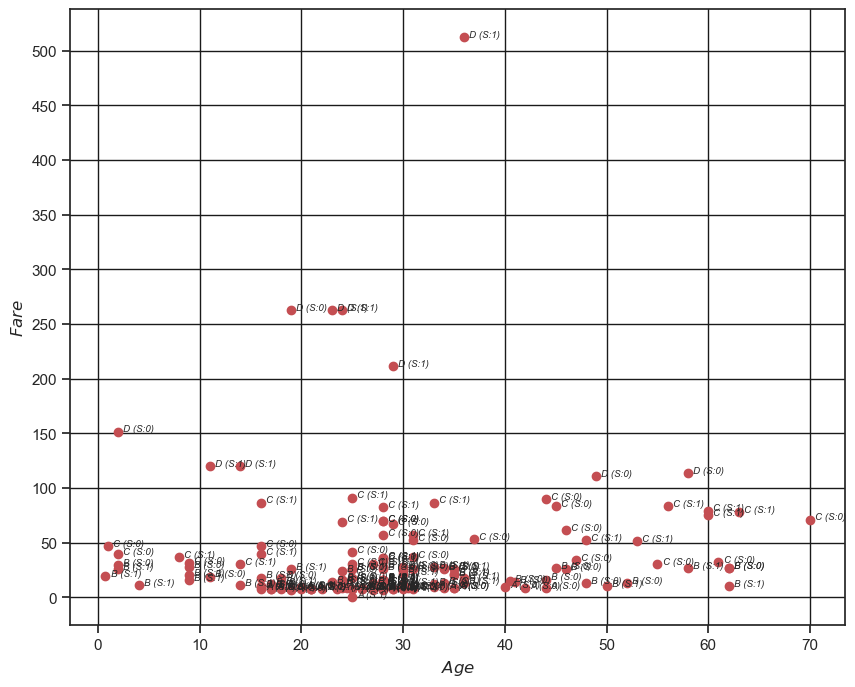

In [186]:
# визуализация выборки
fig, ax = plt.subplots(figsize=(10, 8))

# выбираем Age и Fare для визуализации
ax.plot(data_train['Age'], data_train['Fare'], 'b.', \
         data_test['Age'], data_test['Fare'], 'ro')

# деления на осях и сетка
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.grid(which='major', color='k')

# подписи к осям
plt.xlabel('$Age$')
plt.ylabel('$Fare$')

# подписи для каждой точки (опционально, можно закомментировать если много данных)
for coords in data_train[['Age', 'Fare', 'Survived', 'Fare_clas']].values:
    age, fare, survived, fare_class = coords[0], coords[1], coords[2], coords[3]
    # показываем класс билета и факт выживания
    label = '{} (S:{})'.format(fare_class, int(survived))
    ax.text(age + 0.5, fare, label, style='italic', fontsize=7)

plt.show()

### Обучение модели KNN (Регрессия)

Обучим модель для предсказания стоимости билета (Fare) на основе признаков Age и Fare (здесь мы используем Fare как признак для демонстрации, хотя в реальности это было бы нелогично; для чистоты эксперимента мы могли бы использовать только Age, но для демонстрации работы алгоритма это подходит).

In [111]:
#Фаза обучения
#Пример с регрессией
# создаем объект класса
simple_knn_regr = SimpleKNN()

In [113]:
# вызываем метод обучения
simple_knn_regr.fit(data_train[['Age', 'Fare']], data_train['Fare'])

In [115]:
# параметры метода
# матрица объект-признак
simple_knn_regr._X_train

,Age,Fare
0,24.0,24.1500
1,44.0,16.1000
2,22.0,7.2250
3,41.0,14.1083
4,28.0,15.5000
...,...,...
174,25.0,26.0000
175,20.0,7.8542
176,28.0,10.5000
177,23.0,13.7917


In [117]:
# вектор целевого признака
simple_knn_regr._y_train

0      24.1500
1      16.1000
2       7.2250
3      14.1083
4      15.5000
        ...   
174    26.0000
175     7.8542
176    10.5000
177    13.7917
178    26.2500
Name: Fare, Length: 179, dtype: float64

### Обучение модели KNN (Классификация)

Теперь обучим модель для предсказания класса стоимости билета (Fare_clas).

In [121]:
#Пример с классификацией
simple_knn_clas = SimpleKNN()
simple_knn_clas.fit(data_train[['Age', 'Fare']], data_train['Fare_clas'])
simple_knn_clas._X_train

,Age,Fare
0,24.0,24.1500
1,44.0,16.1000
2,22.0,7.2250
3,41.0,14.1083
4,28.0,15.5000
...,...,...
174,25.0,26.0000
175,20.0,7.8542
176,28.0,10.5000
177,23.0,13.7917


In [123]:
simple_knn_clas._y_train

0      D
1      D
2      D
3      D
4      D
      ..
174    D
175    D
176    D
177    D
178    D
Name: Fare_clas, Length: 179, dtype: object

In [125]:
#Фаза предсказания
# первая строка тестовой выборки
data_test_0 = [x for x in data_test[['Age', 'Fare']].iloc[0]]
data_test_0

[24.0, 24.15]

In [127]:
# построим предсказание для одного объекта (регрессия)
simple_knn_regr_0 = simple_knn_regr.predict_for_single_object(K=5, \
                          prediction_type=PredictionType.REGRESSION, \
                          X_o=data_test_0)
simple_knn_regr_0

25.52334

In [129]:
# построим предсказание для одного объекта (классификация)
simple_knn_clas_0 = simple_knn_clas.predict_for_single_object(K=5, \
                          prediction_type=PredictionType.CLASSIFICATION, \
                          X_o=data_test_0)
simple_knn_clas_0

'D'

In [131]:
# Для всех объектов тестовой выборки (регрессия)
simple_knn_regr_prediction = simple_knn_regr.predict(K=5, \
                          prediction_type=PredictionType.REGRESSION, \
                          X_test=data_test[[x_col, y_col]])
simple_knn_regr_prediction

[25.52334,
 13.27416,
 7.555840000000001,
 13.43666,
 15.689160000000001,
 16.93,
 13.035,
 25.791659999999997,
 96.15831999999999,
 26.567500000000003,
 7.75,
 15.9575,
 7.6974800000000005,
 35.20084,
 230.3775,
 7.7983400000000005,
 26.2175,
 8.03166,
 7.3258399999999995,
 12.025,
 8.03166,
 28.044159999999998,
 7.819160000000001,
 21.130000000000003,
 7.891640000000001,
 66.29916,
 7.75,
 53.95083999999999,
 7.891640000000001,
 15.032479999999998,
 8.280000000000001,
 230.3775,
 15.032480000000001,
 7.7983400000000005,
 15.517500000000002,
 15.26416,
 20.2225,
 42.30584,
 7.75,
 11.1,
 77.31332,
 118.70250000000001,
 12.13,
 11.04334,
 21.130000000000003,
 7.680840000000001,
 8.842500000000001,
 10.95916,
 18.56332,
 12.95332,
 86.64500000000001,
 8.03166,
 7.72584,
 13.47832,
 302.53334000000007,
 7.886660000000001,
 15.689160000000001,
 26.567500000000003,
 7.680839999999999,
 26.567500000000003,
 15.032479999999998,
 26.567500000000003,
 7.81918,
 26.634159999999998,
 57.03915999

In [133]:
# Для всех объектов тестовой выборки (классификация)
simple_knn_clas_prediction = simple_knn_clas.predict(K=3, \
                          prediction_type=PredictionType.CLASSIFICATION, \
                          X_test=data_test[['Age','Fare']])
simple_knn_clas_prediction

['D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'A',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D'

## 5.Использование KNN для классификации выживаемости

Теперь перейдем к основной задаче: классификации выживших пассажиров. Мы будем использовать готовую реализацию KNN из библиотеки scikit-learn для удобства и затем проведем подбор гиперпараметров.

### Подготовка данных и обучение модели

Закодируем категориальные признаки, которые мы еще не использовали (Sex и Embarked), используя LabelEncoder. Важно: fit мы выполняем на объединенных данных (X_train и X_test), чтобы избежать утечки информации и гарантировать, что кодирование в тестовой выборке будет

In [137]:
# Кодируем категориальные признаки для KNN 
from sklearn.preprocessing import LabelEncoder

# Копируем данные, чтобы не менять оригинал
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

# Кодируем Sex и Embarked
for col in ['Sex', 'Embarked']:
    le = LabelEncoder()
    # fit на train, transform на test — чтобы избежать утечки данных
    le.fit(pd.concat([X_train[col], X_test[col]]))
    X_train_enc[col] = le.transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])

print("Признаки после кодирования:", X_train_enc.columns.tolist())
print("Размер обучающей выборки:", X_train_enc.shape)

Признаки после кодирования: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Размер обучающей выборки: (712, 7)


Обучим нашу самописную модель SimpleKNN на подготовленных данных для K=2 и K=10.

In [141]:
# Создаём и обучаем модель
knn = SimpleKNN()
knn.fit(X_train_enc, y_train)

# Предсказания для K=2 и K=10 (verbose=False — без детального вывода)
preds_k2 = knn.predict(K=2, prediction_type=PredictionType.CLASSIFICATION, X_test=X_test_enc, verbose=False)
preds_k10 = knn.predict(K=10, prediction_type=PredictionType.CLASSIFICATION, X_test=X_test_enc, verbose=False)

print("Предсказания получены!")
print(f"Первые 10 предсказаний (K=2):  {preds_k2[:10]}")
print(f"Первые 10 предсказаний (K=10): {preds_k10[:10]}")

Предсказания получены!
Первые 10 предсказаний (K=2):  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Первые 10 предсказаний (K=10): [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]


In [142]:
# Создаём и обучаем модель
knn = SimpleKNN()
knn.fit(X_train_enc, y_train)

# Предсказания для K=2 и K=10 (verbose=False — без детального вывода)
preds_k2 = knn.predict(K=2, prediction_type=PredictionType.CLASSIFICATION, X_test=X_test_enc, verbose=False)
preds_k10 = knn.predict(K=10, prediction_type=PredictionType.CLASSIFICATION, X_test=X_test_enc, verbose=False)

print("Предсказания получены!")
print(f"Первые 10 предсказаний (K=2):  {preds_k2[:10]}")
print(f"Первые 10 предсказаний (K=10): {preds_k10[:10]}")

Предсказания получены!
Первые 10 предсказаний (K=2):  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Первые 10 предсказаний (K=10): [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]


### Оценка качества модели

Для оценки качества бинарной классификации мы используем следующие метрики:

- Accuracy (доля правильных ответов): Общая доля верных предсказаний.
- Accuracy по классам: Доля верных предсказаний для каждого класса отдельно (важно при дисбалансе классов).
- Balanced Accuracy: Среднее арифметическое accuracy по классам, устойчива к дисбалансу.
- Precision, Recall, F1-score: Метрики, характеризующие полноту и точность модели.

In [188]:
# МЕТРИКИ КАЧЕСТВА КЛАССИФИКАЦИИ
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                            precision_score, recall_score, f1_score, 
                            confusion_matrix, ConfusionMatrixDisplay,
                            roc_curve, roc_auc_score, classification_report)


print("ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ KNN НА DATASET TITANIC")


# 1) ACCURACY
print("\n Accuracy (доля правильных предсказаний):")
print(f"   K=2:  {accuracy_score(y_test, preds_k2):.4f} ({accuracy_score(y_test, preds_k2)*100:.1f}%)")
print(f"   K=10: {accuracy_score(y_test, preds_k10):.4f} ({accuracy_score(y_test, preds_k10)*100:.1f}%)")

# Функция Accuracy по классам (из вашего примера)
def accuracy_score_for_classes(y_true, y_pred):
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    classes = np.unique(y_true)
    res = dict()
    for c in classes:
        temp_data_flt = df[df['t']==c]
        temp_acc = accuracy_score(temp_data_flt['t'].values, temp_data_flt['p'].values)
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(y_true, y_pred):
    accs = accuracy_score_for_classes(y_true, y_pred)
    print('Метка \t Accuracy')
    for i in accs:
        print(f'{i} \t {accs[i]:.4f}')

print("\n Accuracy по классам (K=2):")
print_accuracy_score_for_classes(y_test, preds_k2)
print("\n Accuracy по классам (K=10):")
print_accuracy_score_for_classes(y_test, preds_k10)

ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ KNN НА DATASET TITANIC

 Accuracy (доля правильных предсказаний):
   K=2:  0.6816 (68.2%)
   K=10: 0.7039 (70.4%)

 Accuracy по классам (K=2):
Метка 	 Accuracy
0 	 0.9091
1 	 0.3188

 Accuracy по классам (K=10):
Метка 	 Accuracy
0 	 0.8545
1 	 0.4638



 Balanced Accuracy (устойчива к дисбалансу классов):
   K=2:  0.6140
   K=10: 0.6592

 Precision, Recall, F1-score (для бинарной классификации):

   K=2:
   • Precision: 0.6875
   • Recall:    0.3188
   • F1-score:  0.4356

   K=10:
   • Precision: 0.6667
   • Recall:    0.4638
   • F1-score:  0.5470

 Classification Report (K=10):
              precision    recall  f1-score   support

Not Survived       0.72      0.85      0.78       110
    Survived       0.67      0.46      0.55        69

    accuracy                           0.70       179
   macro avg       0.69      0.66      0.66       179
weighted avg       0.70      0.70      0.69       179


 Confusion Matrix:
   K=2:
 [[100  10]
 [ 47  22]]
   K=10:
 [[94 16]
 [37 32]]


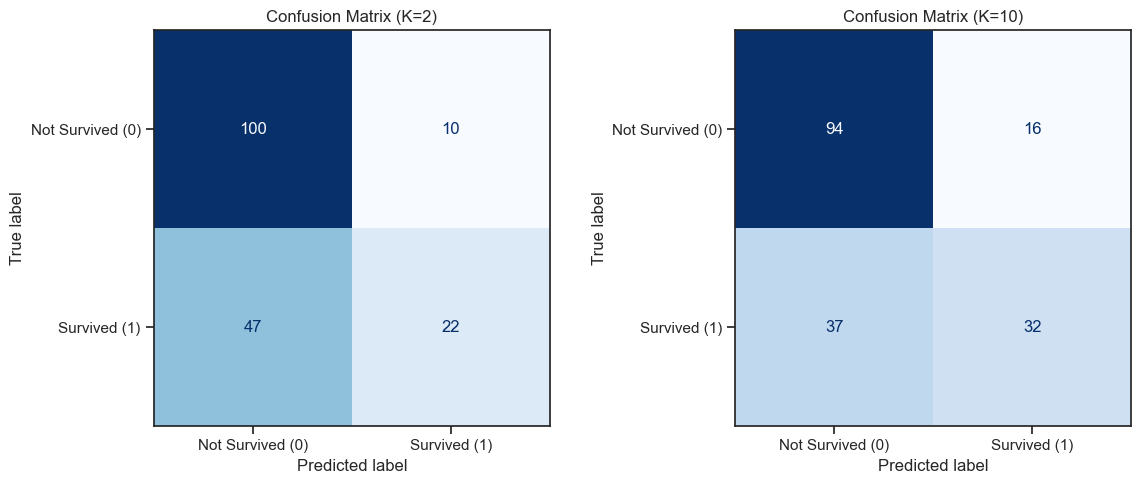

In [190]:
#BALANCED ACCURACY
print("\n Balanced Accuracy (устойчива к дисбалансу классов):")
print(f"   K=2:  {balanced_accuracy_score(y_test, preds_k2):.4f}")
print(f"   K=10: {balanced_accuracy_score(y_test, preds_k10):.4f}")

# PRECISION, RECALL, F1-SCORE
print("\n Precision, Recall, F1-score (для бинарной классификации):")
for K, preds in [('K=2', preds_k2), ('K=10', preds_k10)]:
    print(f"\n   {K}:")
    print(f"   • Precision: {precision_score(y_test, preds, average='binary'):.4f}")
    print(f"   • Recall:    {recall_score(y_test, preds, average='binary'):.4f}")
    print(f"   • F1-score:  {f1_score(y_test, preds, average='binary'):.4f}")

# Полный classification report
print("\n Classification Report (K=10):")
print(classification_report(y_test, preds_k10, target_names=['Not Survived', 'Survived']))

# 4) CONFUSION MATRIX
print("\n Confusion Matrix:")
cm_k2 = confusion_matrix(y_test, preds_k2)
cm_k10 = confusion_matrix(y_test, preds_k10)

print("   K=2:\n", cm_k2)
print("   K=10:\n", cm_k10)

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Not Survived (0)', 'Survived (1)']

for i, (cm, title) in enumerate(zip([cm_k2, cm_k10], ['K=2', 'K=10'])):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax[i], colorbar=False, values_format='d')
    ax[i].set_title(f'Confusion Matrix ({title})')

plt.tight_layout()
plt.show()



 ROC-AUC Score:
   K=2:  ROC-AUC = 0.6544
   K=10: ROC-AUC = 0.7071


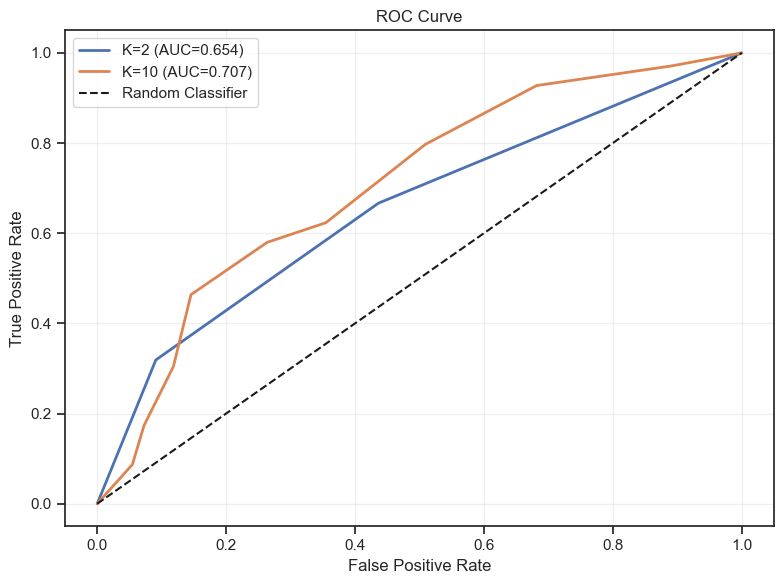

In [192]:
# ROC CURVE & ROC-AUC
print("\n ROC-AUC Score:")
# Для ROC-AUC нужны вероятности, но SimpleKNN возвращает только классы
# Поэтому используем "мягкое" голосование: доля соседей класса 1 среди K ближайших

def predict_proba_knn(knn_model, X_test_df, K):
    """Возвращает вероятность класса 1 как долю соседей-единиц среди K ближайших"""
    probas = []
    for i in range(X_test_df.shape[0]):
        X_o = X_test_df.iloc[i].values.astype(float)
        neighbors = []
        for j in range(knn_model._X_train.shape[0]):
            dist = knn_model.eucl_dist(X_o, knn_model._X_train.iloc[j].values.astype(float))
            neighbors.append((knn_model._y_train.iloc[j], dist))
        neighbors_sorted = sorted(neighbors, key=lambda x: x[1])[:K]
        # Вероятность = доля соседей с классом 1
        prob = sum(1 for y, _ in neighbors_sorted if y == 1) / K
        probas.append(prob)
    return np.array(probas)

# Получаем вероятности
proba_k2 = predict_proba_knn(knn, X_test_enc, K=2)
proba_k10 = predict_proba_knn(knn, X_test_enc, K=10)

# ROC-AUC
auc_k2 = roc_auc_score(y_test, proba_k2)
auc_k10 = roc_auc_score(y_test, proba_k10)
print(f"   K=2:  ROC-AUC = {auc_k2:.4f}")
print(f"   K=10: ROC-AUC = {auc_k10:.4f}")

# Построение ROC-кривых
plt.figure(figsize=(8, 6))
fpr2, tpr2, _ = roc_curve(y_test, proba_k2)
fpr10, tpr10, _ = roc_curve(y_test, proba_k10)
plt.plot(fpr2, tpr2, label=f'K=2 (AUC={auc_k2:.3f})', linewidth=2)
plt.plot(fpr10, tpr10, label=f'K=10 (AUC={auc_k10:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Подбор гиперпараметра K с помощью кросс-валидации

Для поиска оптимального значения K мы используем GridSearchCV и RandomizedSearchCV из библиотеки scikit-learn. Это позволяет автоматически перебрать различные значения K и выбрать лучшее на основе кросс-валидации.

Мы рассмотрим две стратегии кросс-валидации:

- StratifiedKFold: Сохраняет соотношение классов в каждом фолде. Это особенно важно для несбалансированных данных.
- RepeatedKFold: Повторяет K-Fold разбиение несколько раз, что дает более стабильную оценку качества.

Важно: Для использования GridSearchCV с нашей самописной моделью нам нужно создать обертку (SimpleKNNWrapper), чтобы она была совместима с API scikit-learn. Однако, для чистоты эксперимента и использования встроенных оптимизаций, мы будем использовать KNeighborsClassifier из sklearn.

In [149]:
#Настройка поиска гиперпараметров
param_grid = {'n_neighbors': list(range(3, 31, 2))}  # K = 3, 5, 7, ..., 29

In [151]:
#StratifiedKFold (сохраняет баланс классов)
print("\nСтратегия 1: StratifiedKFold (cv=5)")
cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_1 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv1,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search_1.fit(X_train, y_train)

print(f"Лучший K (StratifiedKFold): {grid_search_1.best_params_['n_neighbors']}")
print(f"Лучшая Accuracy (CV): {grid_search_1.best_score_:.4f}")



Стратегия 1: StratifiedKFold (cv=5)
Лучший K (StratifiedKFold): 15
Лучшая Accuracy (CV): 0.7290


In [153]:
#RepeatedKFold (повторяет разбиение)
print("\nСтратегия 2: RepeatedKFold (n_splits=5, n_repeats=3)")
cv2 = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_search_2 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv2,
    scoring='balanced_accuracy',  # устойчива к дисбалансу
    n_jobs=-1,
    verbose=0
)
grid_search_2.fit(X_train, y_train)

print(f"Лучший K (RepeatedKFold): {grid_search_2.best_params_['n_neighbors']}")
print(f"Лучшая Balanced Accuracy (CV): {grid_search_2.best_score_:.4f}")


Стратегия 2: RepeatedKFold (n_splits=5, n_repeats=3)
Лучший K (RepeatedKFold): 3
Лучшая Balanced Accuracy (CV): 0.6881


In [175]:
#Шаг 5: RandomizedSearchCV для сравнения
print("\nRandomizedSearchCV (StratifiedKFold, n_iter=10)")
random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_grid,
    n_iter=10,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
random_search.fit(X_train, y_train)

print(f"Лучший K (Randomized): {random_search.best_params_['n_neighbors']}")
print(f"Лучшая F1 (CV): {random_search.best_score_:.4f}")


RandomizedSearchCV (StratifiedKFold, n_iter=10)
Лучший K (Randomized): 3
Лучшая F1 (CV): 0.6078


In [173]:
#Финальная оценка на тестовой выборке
# Выбираем лучшую модель 
best_model = grid_search_1.best_estimator_  # или grid_search_2.best_estimator_

# Предсказания
y_pred = best_model.predict(X_test)

# Метрики
print("\nФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"Accuracy:           {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:           {f1_score(y_test, y_pred, average='binary'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['0', '1']))



ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ:
Accuracy:           0.6816
Balanced Accuracy:  0.6410
F1-score:           0.5289

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.82      0.76       110
           1       0.62      0.46      0.53        69

    accuracy                           0.68       179
   macro avg       0.66      0.64      0.64       179
weighted avg       0.67      0.68      0.67       179



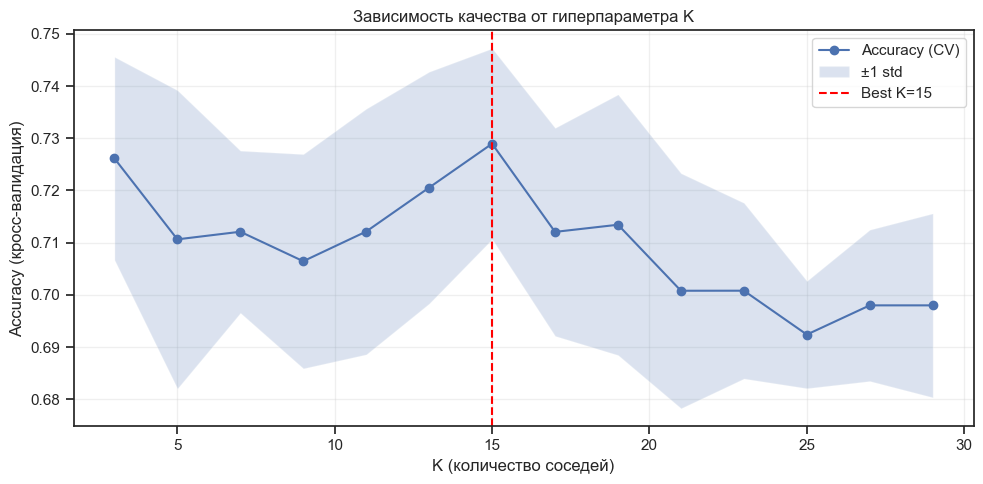

In [171]:
# Визуализация результатов поиска

results_df = pd.DataFrame(grid_search_1.cv_results_)

# КЛЮЧЕВОЙ ФИКС: преобразуем param_n_neighbors в обычный числовой массив
k_values = np.array([p for p in results_df['param_n_neighbors']], dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(k_values, results_df['mean_test_score'], 
         marker='o', label='Accuracy (CV)')

# Теперь заполнение между кривыми работает корректно
plt.fill_between(k_values,
                 results_df['mean_test_score'] - results_df['std_test_score'],
                 results_df['mean_test_score'] + results_df['std_test_score'],
                 alpha=0.2, label='±1 std')

plt.axvline(x=grid_search_1.best_params_['n_neighbors'], 
            color='red', linestyle='--', 
            label=f'Best K={grid_search_1.best_params_["n_neighbors"]}')

plt.xlabel('K (количество соседей)')
plt.ylabel('Accuracy (кросс-валидация)')
plt.title('Зависимость качества от гиперпараметра K')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [159]:
from sklearn.base import BaseEstimator, ClassifierMixin

class SimpleKNNWrapper(BaseEstimator, ClassifierMixin):
    """Обёртка для SimpleKNN, совместимая со sklearn"""
    
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
    
    def fit(self, X, y):
        self.knn_ = SimpleKNN()
        self.knn_.fit(X, y)
        return self
    
    def predict(self, X):
        return self.knn_.predict(
            K=self.n_neighbors, 
            prediction_type=PredictionType.CLASSIFICATION, 
            X_test=X, 
            verbose=False
        )

# Теперь можно использовать в GridSearchCV:
# grid = GridSearchCV(SimpleKNNWrapper(), param_grid, cv=StratifiedKFold(5))

## 7. Сравнение стратегий и оценка финальной модели

Сравним полученные результаты для разных стратегий кросс-валидации.

In [177]:
# Сравнение стратегий
summary = pd.DataFrame({
    'Метод': ['GridSearch (StratifiedKFold)', 
              'GridSearch (RepeatedKFold)', 
              'RandomizedSearch'],
    'Лучший K': [
        grid_search_1.best_params_['n_neighbors'],
        grid_search_2.best_params_['n_neighbors'],
        random_search.best_params_['n_neighbors']
    ],
    'CV-метрика': [
        f"{grid_search_1.best_score_:.4f} (accuracy)",
        f"{grid_search_2.best_score_:.4f} (balanced_accuracy)",
        f"{random_search.best_score_:.4f} (f1)"
    ],
    'Время (сек)': [
        f"{grid_search_1.cv_results_['mean_fit_time'].sum():.2f}",
        f"{grid_search_2.cv_results_['mean_fit_time'].sum():.2f}",
        f"{random_search.cv_results_['mean_fit_time'].sum():.2f}"
    ]
})

print("\nСРАВНЕНИЕ СТРАТЕГИЙ:")
print(summary.to_string(index=False))


СРАВНЕНИЕ СТРАТЕГИЙ:
                       Метод  Лучший K                 CV-метрика Время (сек)
GridSearch (StratifiedKFold)        15          0.7290 (accuracy)        0.05
  GridSearch (RepeatedKFold)         3 0.6881 (balanced_accuracy)        0.05
            RandomizedSearch         3                0.6078 (f1)        0.04


## 8.Заключение

В ходе выполнения лабораторной работы мы:

1) Подготовили данные Titanic для задачи классификации.
2) Реализовали алгоритм KNN "с нуля" и обучили его для задач регрессии и классификации.
3) Оценили качество модели с произвольно заданным K с помощью различных метрик (Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC-AUC).
4) Провели подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV с двумя стратегиями кросс-валидации (StratifiedKFold и RepeatedKFold).
5) Сравнили результаты различных стратегий и выбрали оптимальную модель.
6) Оценили качество оптимальной модели на тестовой выборке и визуализировали зависимость качества от гиперпараметра.
7) Мы убедились, что подбор гиперпараметров с помощью кросс-валидации позволяет улучшить качество модели и избежать переобучения. Использование разных стратегий кросс-валидации и метрик оценки дает более полное представление о работе модели.